### MDART PAPER: FIGURE 2

In [1]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import nibabel as nib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Rectangle
import seaborn as sns
from nilearn import image
# Private nilearn helper (not part of the public API) -- needed because
# plot_roi's public `dim` arg cannot express a fixed background vmin/vmax
# window; this lets us set bg_vmin/bg_vmax explicitly instead.
from nilearn.plotting.img_plotting import _plot_img_with_bg

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import fdrcorrection

In [2]:
# ---- Helpers for plotting ----
def p_to_stars(p: float, show_ns: bool = False) -> str:
    """Convert p-value to significance stars."""
    if p is None or np.isnan(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns" if show_ns else ""

def add_contrast_line_and_stars(
    ax,
    x1: float,
    x2: float,
    y: float,
    stars: str,
    line_lw: float = 0.6,
    star_fs: int = 7,
    y_pad_frac: float = 0.015,
):
    """
    Draw a horizontal line between x1 and x2 at height y, and put `stars` above it.
    y_pad_frac is a fraction of current y-range.
    """
    if not stars:
        return

    # Horizontal line (center-to-center)
    ax.plot([x1, x2], [y, y], color="black", lw=line_lw, solid_capstyle="butt")

    # Put stars a bit above the line
    ymin, ymax = ax.get_ylim()
    y_pad = (ymax - ymin) * y_pad_frac
    ax.text((x1 + x2) / 2, y + y_pad, stars,
            ha="center", va="bottom", fontsize=star_fs, color="black")
    
def add_panel_label(
    ax,
    label: str,
    x: float = -0.15,
    y: float = 1.05,
    fontsize: int = 6.5,
    fontweight: str = "bold",
):
    """Add a panel label above the y-axis line."""
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight=fontweight,
        va="bottom",
        ha="left",
        clip_on=False,
    )

def add_multiple_contrast_lines_and_stars(
    ax,
    comparisons,  # [(x1, x2, stars), ...]
    y_base=None,
    base_pad_frac=0.08,
    step_frac=0.16,
    line_lw=0.6,
    star_fs=7,
    y_pad_frac=0.015,
):
    comps = [(x1, x2, s) for (x1, x2, s) in comparisons if s]
    if not comps:
        return

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin

    # A good default: start above the tallest bar currently on this axis
    # (only look at actual bar Rectangles, not background axvspan patches)
    if y_base is None:
        bar_tops = [p.get_height() for p in ax.patches if isinstance(p, Rectangle)]
        y_base = max(bar_tops) if bar_tops else ymax

    y0 = y_base + base_pad_frac * yr

    for i, (x1, x2, stars) in enumerate(comps):
        y = y0 + i * step_frac * yr
        add_contrast_line_and_stars(
            ax=ax, x1=x1, x2=x2, y=y, stars=stars,
            line_lw=line_lw, star_fs=star_fs, y_pad_frac=y_pad_frac
        )

    # prevent clipping
    top_needed = y0 + (len(comps)-1)*step_frac*yr + (y_pad_frac+0.05)*yr
    if top_needed > ymax:
        ax.set_ylim(ymin, top_needed)

def save_figure(
    fig,
    out_dir,
    filename,
    dpi=600,
    save_pdf=True,
    save_png=True,
    facecolor="white",
    bbox_inches="tight",
):
    """ Save figure in PDF and PNG format."""

    if save_pdf:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.pdf"),
            dpi=dpi,
            bbox_inches=bbox_inches,
        )

    if save_png:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.png"),
            dpi=dpi,
            bbox_inches=bbox_inches,
            facecolor=facecolor,
        )

#### Figure 2 - Panel a

C:\Users\psiok\AppData\Local\Temp\ipykernel_20516\962428990.py:50: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
C:\Users\psiok\AppData\Local\Temp\ipykernel_20516\962428990.py:50: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.4}` instead.

  sns.barplot(
C:\Users\psiok\AppData\Local\Temp\ipykernel_20516\962428990.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=6, fontdict={"family": "Arial"})


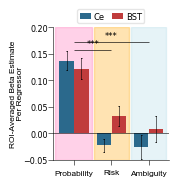

In [3]:
# -----------------------
# Paths to df and output
# -----------------------
long_csv = "../data/figure2/ce_bst_betas_long_fullNoPE.csv"
OUT_DIR = "../outputs/figures"  # created if missing
os.makedirs(OUT_DIR, exist_ok=True)
# -----------------------
# Load + basic cleaning
# -----------------------
df = pd.read_csv(long_csv)

# Keep only regions we want (Ce and BST)
df = df[df["region"].isin(["ce", "bst"])].copy()

# Ensure numeric
df["mean_beta"] = pd.to_numeric(df["mean_beta"], errors="coerce")

# -----------------------
# Exact ordering of regressors and x-axis labels
# -----------------------
order = [
    "Probability (risk/certain trials)",
    '"Risk" (Var[p-threat])',
    "Ambiguity (unknown probability)",
]

x_labels = [
    "Probability",
    "Risk",
    "Ambiguity"
]

# Make regressor categorical to force order
df["regressor"] = pd.Categorical(df["regressor"], categories=order, ordered=True)
df = df.dropna(subset=["regressor"])  # drops anything not in 'order'

# -------------------------
# Setup
# -------------------------
fig2_a, ax = plt.subplots(figsize=(48/25.4, 50/25.4))

# ce_color = "#376680" 
# bst_color = '#cc3030'

bst_color = "#d62626"  
ce_color  = "#1b6e9c"

# -------------------------
# Bar plot
# -------------------------
sns.barplot(
    data=df,
    x="regressor",
    y="mean_beta",
    hue="region",
    order=order,
    errorbar=("se", 1),
    errcolor="black",
    errwidth=0.4,
    capsize=0.05,
    palette=[ce_color, bst_color],
    ax=ax
)

# make bars narrower and re-center them
shrink = 0.95  # smaller = more gap between bars
for patch in ax.patches:
    old_width = patch.get_width()
    new_width = old_width * shrink
    patch.set_width(new_width)
    patch.set_x(patch.get_x() + (old_width - new_width) / 2)

# -------------------------
# Background shading by regressor
# -------------------------
ax.axvspan(-0.5, 0.475, color="hotpink", alpha=0.3, zorder=0)
ax.axvspan(0.525, 1.475, color="orange", alpha=0.3, zorder=0)
ax.axvspan(1.525, 2.475, color="lightblue", alpha=0.3, zorder=0)

# -------------------------
# Reference lines
# -------------------------
ax.axhline(0, color="black", linewidth=0.4)

# -------------------------
# Formatting
# -------------------------
ax.set_ylabel("ROI-Averaged Beta Estimate\n Per Regressor", fontsize=6, fontdict={"family": "Arial"}, labelpad=0)
ax.set_xlabel("")
ax.set_ylim(-0.05, 0.2)

ax.set_xticklabels(x_labels, fontsize=6, fontdict={"family": "Arial"})
ax.tick_params(axis="x", width=0.4)
ax.tick_params(axis='y', labelsize=5.8, width=0.4, pad=0)
# Legend moved above the axes (loc="upper right" inside the plot would collide
# with the Probability-vs-Risk/Ambiguity comparison lines added below).
handles, labels = ax.get_legend_handles_labels()
label_map = {"ce": "Ce", "bst": "BST"}
labels = [label_map.get(l, l) for l in labels]

ax.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    fontsize=6,
    title="",
    framealpha=0.5,
    frameon=True,
    columnspacing=0.8,
    handlelength=1.3,
    handletextpad=0.4,
    borderpad=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)
ax.margins(x=0.025)
# add_panel_label(ax, "a", x=-0.133, y=1.08)

# -------------------------
# Comparison lines: Probability vs Risk, Probability vs Ambiguity,
# pooled across region (Ce and BST each independently significant at
# P < 0.001 for both comparisons; see stats below), so a single line
# spans the full width of each regressor pair rather than one line
# per region.
# -------------------------
comparisons = [
    (0, 1, "***"),  # Probability vs Risk
    (0, 2, "***"),  # Probability vs Ambiguity
]

add_multiple_contrast_lines_and_stars(
    ax, comparisons,
    step_frac=0.06,      # 1. vertical gap between the two lines
    base_pad_frac=0.08,  # gap between tallest bar and the first line
    line_lw=0.45,         # 2. line thickness
    star_fs=6,           # 3. star font size
)


plt.tight_layout()

save_figure(
    fig=fig2_a,
    out_dir=OUT_DIR,
    filename="Fig2_a",
    dpi=600,
    save_pdf=True,
    save_png=True,
    facecolor="white",
    bbox_inches="tight",
)

##### Statistics of Figure 2, Panel a:

In [4]:
model = smf.mixedlm(
    "mean_beta ~ C(regressor) * C(region)",
    data=df,
    groups=df["subject"]
).fit()

print(model.summary())

                                  Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  mean_beta
No. Observations:                  606                      Method:                              REML     
No. Groups:                        101                      Scale:                               0.0368   
Min. group size:                   6                        Log-Likelihood:                      110.9310 
Max. group size:                   6                        Converged:                           Yes      
Mean group size:                   6.0                                                                    
----------------------------------------------------------------------------------------------------------
                                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [5]:
### Post-hoc tests for planned contrasts ###

tests = {
    "BST: Probability (Intercept)": np.array([1, 0, 0, 0, 0, 0]),
    "Ce: Probability (Intercept + region[ce])": np.array([1, 0, 0, 1, 0, 0]),
    "CE: Probability vs Risk": np.array([0, 1, 0, 0, 1, 0]),
    "CE: Probability vs Ambiguity": np.array([0, 0, 1, 0, 0, 1]),
    "Risk: CE vs BST": np.array([0, 0, 0, 1, 1, 0]),
    "Ambiguity: CE vs BST": np.array([0, 0, 0, 1, 0, 1]),
    "BST: Risk (vs 0)": np.array([1, 1, 0, 0, 0, 0]),
    "BST: Ambiguity (vs 0)": np.array([1, 0, 1, 0, 0, 0]),
    "Ce: Risk (vs 0)": np.array([1, 1, 0, 1, 1, 0]),
    "Ce: Ambiguity (vs 0)": np.array([1, 0, 1, 1, 0, 1]),
}


rows = []
for name, vec in tests.items():
    tt = model.t_test(np.atleast_2d(vec))
    rows.append({
        "test": name,
        "estimate": float(tt.effect[0]),
        "se": float(tt.sd[0]),
        "z": float(tt.tvalue[0][0]),
        "p": float(tt.pvalue),
    })

contrast_df = pd.DataFrame(rows)

# FDR correction across all planned contrasts
reject, p_fdr = fdrcorrection(contrast_df["p"].to_numpy(), alpha=0.05, method="poscorr")
contrast_df["p_fdr"] = p_fdr
contrast_df["sig_fdr"] = reject

print(contrast_df)

                                       test  estimate        se         z  \
0              BST: Probability (Intercept)  0.122013  0.019619  6.219231   
1  Ce: Probability (Intercept + region[ce])  0.137327  0.019619  6.999827   
2                   CE: Probability vs Risk -0.159518  0.026989 -5.910526   
3              CE: Probability vs Ambiguity -0.162806  0.026989 -6.032360   
4                           Risk: CE vs BST -0.054337  0.026989 -2.013317   
5                      Ambiguity: CE vs BST -0.033411  0.026989 -1.237969   
6                          BST: Risk (vs 0)  0.032146  0.019619  1.638549   
7                     BST: Ambiguity (vs 0)  0.007932  0.019619  0.404323   
8                           Ce: Risk (vs 0) -0.022191  0.019619 -1.131113   
9                      Ce: Ambiguity (vs 0) -0.025479  0.019619 -1.298716   

              p         p_fdr  sig_fdr  
0  4.995972e-10  2.497986e-09     True  
1  2.562790e-12  2.562790e-11     True  
2  3.410171e-09  8.525427e-09

C:\Users\psiok\AppData\Local\Temp\ipykernel_20516\3691574934.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(tt.sd[0]),


#### Figure 2 - Panel c-d
- No stats ran for these two panels as they are for visualization only.

In [6]:
# -----------------------------
# Paths / config
# -----------------------------
# Data
data_path = "../data/figure2/ce_bst_betas_long_cueType.csv"

# ROIs + template
template_path = "../data/figure2/template_T1.nii.gz"
bst_roi_path = "../data/figure2/roi_bst.nii"
ce_roi_path = "../data/figure2/roi_ce.nii"

# -----------------------------
# Regex helpers (regressor naming)
# -----------------------------
P_NONAMB_RE = re.compile(r"^p(\d+)_c0$")
A_RE = re.compile(r"^a(\d+)_c0$")

# -----------------------------
# Load inputs
# -----------------------------
df_long = pd.read_csv(data_path)
template = nib.load(template_path)


# Resample ROIs to match template (1mm)
bst = image.resample_to_img(bst_roi_path, template, interpolation='nearest')
ce  = image.resample_to_img(ce_roi_path,  template, interpolation='nearest')

# Binarize (partial-volume masks may have float values)
bst = image.math_img("img > 0", img=bst)
ce  = image.math_img("img > 0", img=ce)

# Quick sanity check
print("Template shape:", template.shape)
print("BST shape after resample:", bst.shape)
print("CE shape after resample:", ce.shape)

Template shape: (182, 218, 182)
BST shape after resample: (182, 218, 182)
CE shape after resample: (182, 218, 182)


In [7]:
def add_predictors_from_regressor(df: pd.DataFrame, regressor_col: str = "regressor") -> pd.DataFrame:
    """
    Adds:
      - p (int) for rows with regressor like p010_c0 (non-ambiguous probability cues)
      - amb (int) for rows with regressor like a030_c0 (ambiguity cues)
      - risk (float) derived from p
      - type: 'p_nonamb' or 'amb' or NaN
    """
    out = df.copy()
    reg = out[regressor_col].astype(str)

    # non-amb probability p###_c0
    p_str = reg.str.extract(r"^p(\d+)_c0$", expand=False)
    out["p"] = pd.to_numeric(p_str, errors="coerce")

    # ambiguity a###_c0
    a_str = reg.str.extract(r"^a(\d+)_c0$", expand=False)
    out["amb"] = pd.to_numeric(a_str, errors="coerce")

    # Risk transform
    out["risk"] = np.where(
        out["p"].notna(),
        np.round((((100 * (((out["p"] / 100) - 0.5) ** 2)) - 25) / 25) * -1, 2),
        np.nan,
    )

    out["type"] = np.where(out["p"].notna(), "p_nonamb",
                    np.where(out["amb"].notna(), "amb", np.nan))
    return out

def prepare_roi_df(df_long: pd.DataFrame, region: str) -> pd.DataFrame:
    df = df_long.loc[df_long["region"].str.lower() == region.lower()].copy()
    df = df.rename(columns={
        "subject": "subj",
        "mean_beta": "Beta"
    })
    df = add_predictors_from_regressor(df)
    return df

df_bst = prepare_roi_df(df_long, region="bst")
df_ce  = prepare_roi_df(df_long, region="ce")

def plot_betas_by_cuetype(df: pd.DataFrame, roi_title: str, axarr):

    df_p = df.loc[df["type"] == "p_nonamb"].copy()
    df_a = df.loc[df["type"] == "amb"].copy()

    # ---------- shared styling ----------
    title_fs = 7         # font size of subplot titles
    label_fs = 6         # font size of x- and y-axis labels
    tick_fs = 5.5        # font size of axis tick labels
    line_w = 0.4         # thickness of plotted lines
    point_s = 12         # size of scatter points
    point_edge_w = 0.3   # thickness of scatter point outlines
    band_alpha = 0.15    # transparency of shaded SE band
    spine_w = 0.4        # thickness of axis spines
    tick_w = 0.4         # thickness of tick marks
    tick_len = 2         # length of tick marks

    # ---------- Panel 1: Probability ----------
    agg_p = (
        df_p.groupby("p", as_index=False)
        .agg(
            Beta=("Beta", "mean"),
            se=("Beta", lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum())),
            risk=("risk", "mean")
        )
    )

    axarr[0].plot(
        agg_p["p"], agg_p["Beta"],
        color="hotpink",
        linewidth=line_w,
        zorder=2
    )

    axarr[0].fill_between(
        agg_p["p"],
        agg_p["Beta"] - agg_p["se"],
        agg_p["Beta"] + agg_p["se"],
        color="hotpink",
        alpha=band_alpha,
        zorder=1
    )

    sns.scatterplot(
        x="p", y="Beta", data=agg_p, hue="risk",
        palette="viridis",
        s=point_s,
        edgecolor="black",
        linewidth=point_edge_w,
        legend=False,
        zorder=3,
        ax=axarr[0]
    )

    # axarr[0].set_title("Probability", fontsize=title_fs, pad=2)
    axarr[0].set_xlabel("Probability", fontsize=label_fs, labelpad=1)
    axarr[0].set_ylabel("ROI-Averaged Beta Estimate\n Per Cue", fontsize=label_fs, labelpad=0.5)
    axarr[0].tick_params(axis="both", labelsize=tick_fs, width=tick_w, length=tick_len, pad=1)

    for spine in axarr[0].spines.values():
        spine.set_linewidth(spine_w)

    # ---------- Panel 2: Risk ----------
    agg_r = (
        df_p.groupby("risk", as_index=False)
        .agg(
            Beta=("Beta", "mean"),
            se=("Beta", lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum()))
        )
    )

    axarr[1].plot(
        agg_r["risk"], agg_r["Beta"],
        color="orange",
        linewidth=line_w,
        zorder=2
    )

    axarr[1].fill_between(
        agg_r["risk"],
        agg_r["Beta"] - agg_r["se"],
        agg_r["Beta"] + agg_r["se"],
        color="orange",
        alpha=band_alpha,
        zorder=1
    )

    sns.scatterplot(
        x="risk", y="Beta", data=agg_r, hue="risk",
        palette="viridis",
        s=point_s,
        edgecolor="black",
        linewidth=point_edge_w,
        legend=False,
        zorder=3,
        ax=axarr[1]
    )

    # axarr[1].set_title("Risk", fontsize=title_fs, pad=2)
    axarr[1].set_xlabel("Risk", fontsize=label_fs, labelpad=1)
    axarr[1].set_ylabel(" ", fontsize=label_fs, labelpad=1)
    axarr[1].tick_params(axis="both", labelsize=tick_fs, width=tick_w, length=tick_len, pad=1)

    for spine in axarr[1].spines.values():
        spine.set_linewidth(spine_w)

    # ---------- Panel 3: Ambiguity ----------
    agg_a = (
        df_a.groupby("amb", as_index=False)
        .agg(
            Beta=("Beta", "mean"),
            se=("Beta", lambda x: x.std(ddof=1) / np.sqrt(x.notna().sum()))
        )
    )

    axarr[2].plot(
        agg_a["amb"], agg_a["Beta"],
        color="blue",
        linewidth=line_w,
        zorder=2
    )

    axarr[2].fill_between(
        agg_a["amb"],
        agg_a["Beta"] - agg_a["se"],
        agg_a["Beta"] + agg_a["se"],
        color="blue",
        alpha=band_alpha,
        zorder=1
    )

    sns.scatterplot(
        x="amb", y="Beta", data=agg_a, hue="amb",
        palette="Blues",
        s=point_s,
        edgecolor="black",
        linewidth=point_edge_w,
        legend=False,
        zorder=3,
        ax=axarr[2]
    )

    # axarr[2].set_title("Ambiguity", fontsize=title_fs, pad=2)
    axarr[2].set_xlabel("Ambiguity", fontsize=label_fs, labelpad=1)
    axarr[2].set_ylabel(" ", fontsize=label_fs, labelpad=1)
    axarr[2].tick_params(axis="both", labelsize=tick_fs, width=tick_w, length=tick_len, pad=1)

    for ax in axarr:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

def plot_roi_plus_betas(df_roi, mask_img, roi_title, template_img, roi_color="red"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Figure layout: top row for ROI image, bottom for 3 plots
        fig = plt.figure(figsize=(100/25.4, 55/25.4))        
        gs = fig.add_gridspec(
            3, 3,
            hspace=0.2,
            wspace=0.35
        )

        ax_top = fig.add_subplot(gs[0, :])
        ax_0   = fig.add_subplot(gs[1:, 0])
        ax_1   = fig.add_subplot(gs[1:, 1])
        ax_2   = fig.add_subplot(gs[1:, 2])

        # solid red colormap
        roi_cmap = mcolors.LinearSegmentedColormap.from_list("roi_cmap", [roi_color, roi_color])

        # Background T1 contrast: plot_roi's public `dim` arg can't express a
        # fixed window (dim=0 is falsy in nilearn's own code, so it silently
        # fell back to the raw whole-volume min/max, which is washed out).
        # Call the private _plot_img_with_bg directly so we can set bg_vmin/
        # bg_vmax explicitly, matching the fixed T1 window (0.4-1.0) used in
        # function_for_plot_brain_slice.ipynb for a consistent look.
        brain_view = _plot_img_with_bg(
            img=mask_img,
            bg_img=template_img,
            display_mode="yx",
            axes=ax_top,
            title=roi_title,
            annotate=False,
            draw_cross=False,
            black_bg=False,
            threshold=0.5,  # plot_roi's default ROI threshold
            bg_vmin=0.4,
            bg_vmax=1.0,
            alpha=1,
            cmap=roi_cmap,
            resampling_interpolation="nearest",
        )

        # White outline around the ROI so it stays visible against the
        # template regardless of local background intensity.
        brain_view.add_contours(
            mask_img,
            levels=[0.5],
            colors="white",
            linewidths=0.45,
        )

        for view_ax in brain_view.axes.values():
            ax = view_ax.ax
            ax.set_rasterization_zorder(10)
            ax.tick_params(labelsize=5.5, width=0.5, length=2, pad=1)
            for txt in ax.texts:
                txt.set_fontsize(5.5)
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)


        if "x" in brain_view.axes:
            brain_view.axes["x"].ax.set_xlim((-60, 60))
            brain_view.axes["x"].ax.set_ylim((-30, 30))

        if "y" in brain_view.axes:
            brain_view.axes["y"].ax.set_xlim((-60, 60))
            brain_view.axes["y"].ax.set_ylim((-30, 30))

        # Plot the 3 panels into the bottom axes
        plot_betas_by_cuetype(df_roi, roi_title=roi_title, axarr=[ax_0, ax_1, ax_2])
        return fig

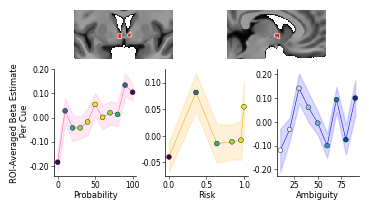

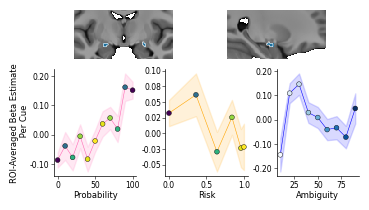

In [8]:
bst_color = "#d62626"  
ce_color  = "#1b6e9c"

fig_bst = plot_roi_plus_betas(df_bst, bst, "", template, roi_color=bst_color )
save_figure(fig_bst, OUT_DIR, "Fig2_b_bst_new")
plt.show()

fig_ce = plot_roi_plus_betas(df_ce, ce, "", template, roi_color=ce_color)
save_figure(fig_ce, OUT_DIR, "Fig2_b_ce_new")
plt.show()